In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Normal data (unchanged from before)
n_normal = 800
temp = np.random.normal(loc=25, scale=3, size=n_normal)
humidity = np.random.normal(loc=50, scale=8, size=n_normal)
gas = np.random.normal(loc=150, scale=25, size=n_normal)
humidity = np.clip(humidity, 0, 100)

# Anomaly pattern A (original): high temp, high gas, LOW humidity
n_anomaly_a = 100
temp_anom_a = np.random.normal(loc=45, scale=5, size=n_anomaly_a)
humidity_anom_a = np.random.normal(loc=15, scale=10, size=n_anomaly_a)
gas_anom_a = np.random.normal(loc=400, scale=40, size=n_anomaly_a)

# Anomaly pattern B (new): high temp, high gas, HIGH humidity
n_anomaly_b = 100
temp_anom_b = np.random.normal(loc=45, scale=5, size=n_anomaly_b)
humidity_anom_b = np.random.normal(loc=85, scale=10, size=n_anomaly_b)
gas_anom_b = np.random.normal(loc=400, scale=40, size=n_anomaly_b)

# Combining both anomaly patterns
temp_anom = np.concatenate([temp_anom_a, temp_anom_b])
humidity_anom = np.concatenate([humidity_anom_a, humidity_anom_b])
gas_anom = np.concatenate([gas_anom_a, gas_anom_b])
humidity_anom = np.clip(humidity_anom, 0, 100)

n_anomaly = n_anomaly_a + n_anomaly_b
print("Total anomalies:", n_anomaly, "(", n_anomaly_a, "low-humidity +", n_anomaly_b, "high-humidity )")

Total anomalies: 200 ( 100 low-humidity + 100 high-humidity )


In [3]:
label_normal = np.zeros(n_normal)
label_anomaly = np.ones(n_anomaly)

temp_all = np.concatenate([temp, temp_anom])
humidity_all = np.concatenate([humidity, humidity_anom])
gas_all = np.concatenate([gas, gas_anom])
class_label = np.concatenate([label_normal, label_anomaly])

print("Total samples:", len(temp_all))
print("Normal count:", int((class_label == 0).sum()))
print("Anomaly count:", int((class_label == 1).sum()))

Total samples: 1000
Normal count: 800
Anomaly count: 200


In [7]:
risk_index = (
    0.4 * (temp_all - 25) +
    0.3 * abs(50 - humidity_all) +
    0.5 * (gas_all - 150) / 10
) + np.random.normal(0, 2, size=len(temp_all))

risk_index = np.clip(risk_index + 30, 0, 100)

print(risk_index[:5])
print("Min:", risk_index.min(), "Max:", risk_index.max(), "Mean:", risk_index.mean())

[30.89233036 32.72877873 30.23649463 32.8833672  27.42466077]
Min: 23.30944635673937 Max: 73.95780416766944 Mean: 37.63464553567171


In [8]:
df = pd.DataFrame({
    'temperature': temp_all,
    'humidity': humidity_all,
    'gas': gas_all,
    'risk_index': risk_index,
    'anomaly_label': class_label
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head(10)

,temperature,humidity,gas,risk_index,anomaly_label
0,26.630081,54.237542,169.615107,35.052716,0.0
1,27.948073,45.738393,151.244342,32.587944,0.0
2,19.477377,49.779881,167.470711,29.768265,0.0
3,23.279014,48.892352,160.918464,33.153745,0.0
4,21.626074,44.456758,130.931881,29.237845,0.0
5,27.807035,42.900063,166.657813,35.808559,0.0
6,22.031186,66.449657,185.490075,34.187497,0.0
7,22.277309,54.462482,124.945314,27.125741,0.0
8,47.360011,24.242701,422.130049,59.994645,1.0
9,22.650240,41.830137,123.657940,30.082111,0.0


In [9]:
# Separating the two anomaly patterns for inspection
anomaly_rows = df[df['anomaly_label'] == 1]
low_humidity_anomalies = anomaly_rows[anomaly_rows['humidity'] < 50]
high_humidity_anomalies = anomaly_rows[anomaly_rows['humidity'] >= 50]

print("Low-humidity anomalies - risk_index mean:", low_humidity_anomalies['risk_index'].mean())
print("High-humidity anomalies - risk_index mean:", high_humidity_anomalies['risk_index'].mean())
print("\nLow-humidity count:", len(low_humidity_anomalies))
print("High-humidity count:", len(high_humidity_anomalies))

Low-humidity anomalies - risk_index mean: 60.887575741283406
High-humidity anomalies - risk_index mean: 61.08515857074809

Low-humidity count: 100
High-humidity count: 100


       temperature     humidity          gas   risk_index  anomaly_label
count  1000.000000  1000.000000  1000.000000  1000.000000      1000.0000
mean     29.052243    50.527409   200.559538    37.634646         0.2000
std       8.814042    17.466935   104.085850    12.147558         0.4002
min      15.276198     0.000000    74.512196    23.309446         0.0000
25%      23.441850    43.962855   139.107219    30.313877         0.0000
50%      25.897798    50.621828   158.156764    32.630833         0.0000
75%      29.623033    57.944349   186.509491    36.586806         0.0000
max      56.819362   100.000000   496.467067    73.957804         1.0000
anomaly_label
0.0    800
1.0    200
Name: count, dtype: int64


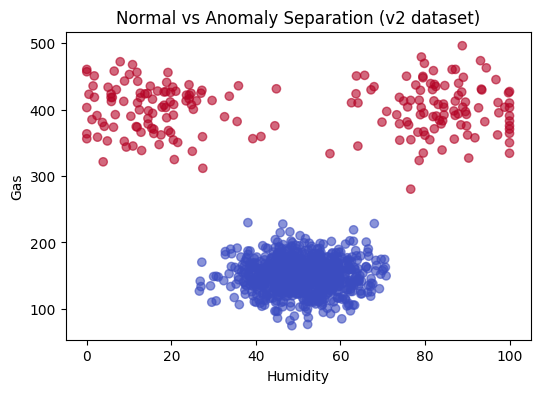

In [10]:
print(df.describe())
print(df['anomaly_label'].value_counts())

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['humidity'], df['gas'], c=df['anomaly_label'], cmap='coolwarm', alpha=0.6)
plt.xlabel('Humidity')
plt.ylabel('Gas')
plt.title('Normal vs Anomaly Separation (v2 dataset)')
plt.savefig('/content/drive/MyDrive/EnviroSense/documents/day2_scatter_v2.png')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['anomaly_label']
)

train_df.to_csv('/content/drive/MyDrive/EnviroSense/data/train_v2.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/EnviroSense/data/test_v2.csv', index=False)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (800, 5)
Test shape: (200, 5)


In [13]:
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, confusion_matrix

X_train = train_df[['temperature', 'humidity', 'gas']]
y_train_reg = train_df['risk_index']
y_train_clf = train_df['anomaly_label']

X_test = test_df[['temperature', 'humidity', 'gas']]
y_test_reg = test_df['risk_index']
y_test_clf = test_df['anomaly_label']

reg_model_v2 = MLPRegressor(hidden_layer_sizes=(8,), max_iter=1000, random_state=42)
reg_model_v2.fit(X_train, y_train_reg)
y_pred_reg_v2 = reg_model_v2.predict(X_test)
mse_v2 = mean_squared_error(y_test_reg, y_pred_reg_v2)

clf_model_v2 = MLPClassifier(hidden_layer_sizes=(8,), max_iter=1000, random_state=42)
clf_model_v2.fit(X_train, y_train_clf)
y_pred_clf_v2 = clf_model_v2.predict(X_test)
acc_v2 = accuracy_score(y_test_clf, y_pred_clf_v2)
prec_v2 = precision_score(y_test_clf, y_pred_clf_v2)
rec_v2 = recall_score(y_test_clf, y_pred_clf_v2)
cm_v2 = confusion_matrix(y_test_clf, y_pred_clf_v2)

print(" V2 Regression ")
print("MSE:", mse_v2)

print("\n V2 Classification ")
print("Accuracy:", acc_v2, "Precision:", prec_v2, "Recall:", rec_v2)
print("Confusion Matrix:\n", cm_v2)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


 V2 Regression 
MSE: 6.985597492376059

 V2 Classification 
Accuracy: 0.98 Precision: 0.9736842105263158 Recall: 0.925
Confusion Matrix:
 [[159   1]
 [  3  37]]


In [14]:
import numpy as np

test_case = np.array([[60, 100, 560]])  # the case that failed before
prediction = clf_model_v2.predict(test_case)
probability = clf_model_v2.predict_proba(test_case)

print("Prediction (0=Normal, 1=Anomaly):", prediction[0])
print("Probabilities [Normal, Anomaly]:", probability[0])

Prediction (0=Normal, 1=Anomaly): 1.0
Probabilities [Normal, Anomaly]: [1.06580276e-04 9.99893420e-01]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


In [15]:
test_case = pd.DataFrame([[60, 100, 560]], columns=['temperature', 'humidity', 'gas'])

In [16]:
import joblib

joblib.dump(reg_model_v2, '/content/drive/MyDrive/EnviroSense/models/reg_fp32_v2.pkl')
joblib.dump(clf_model_v2, '/content/drive/MyDrive/EnviroSense/models/clf_fp32_v2.pkl')

print("V2 FP32 models saved")

V2 FP32 models saved


In [17]:
import numpy as np

def quantize_weights(weights):
    w_min = weights.min()
    w_max = weights.max()
    scale = (w_max - w_min) / 255.0
    quantized = np.round((weights - w_min) / scale - 128)
    quantized = np.clip(quantized, -128, 127).astype(np.int8)
    return quantized, scale, w_min

def quantize_model(model):
    quantized_layers = []
    for layer_weights in model.coefs_:
        q, scale, w_min = quantize_weights(layer_weights)
        quantized_layers.append(q)
    return quantized_layers

reg_quantized_v2 = quantize_model(reg_model_v2)
clf_quantized_v2 = quantize_model(clf_model_v2)

# Check size (should still be 8x smaller, same as before)
reg_fp32_size = sum(w.nbytes for w in reg_model_v2.coefs_)
reg_int8_size = sum(w.nbytes for w in reg_quantized_v2)
print("Regression compression ratio:", round(reg_fp32_size / reg_int8_size, 2), "x smaller")

Regression compression ratio: 8.0 x smaller


In [18]:
def export_simple_header(model, name):
    lines = []
    lines.append(f"// Weights and biases for {name}")
    lines.append(f"#ifndef {name.upper()}_H")
    lines.append(f"#define {name.upper()}_H\n")

    for i, w in enumerate(model.coefs_):
        rows, cols = w.shape
        lines.append(f"const float {name}_w{i}[{rows}][{cols}] = {{")
        for row in w:
            row_str = ", ".join(str(float(v)) for v in row)
            lines.append(f"  {{{row_str}}},")
        lines.append("};\n")

    for i, b in enumerate(model.intercepts_):
        b_str = ", ".join(str(float(v)) for v in b)
        lines.append(f"const float {name}_b{i}[{len(b)}] = {{{b_str}}};\n")

    lines.append("#endif")
    return "\n".join(lines)

reg_header_v2 = export_simple_header(reg_model_v2, "reg_model_v2")
clf_header_v2 = export_simple_header(clf_model_v2, "clf_model_v2")

with open('/content/drive/MyDrive/EnviroSense/models/reg_model_v2.h', 'w') as f:
    f.write(reg_header_v2)

with open('/content/drive/MyDrive/EnviroSense/models/clf_model_v2.h', 'w') as f:
    f.write(clf_header_v2)

print(reg_header_v2[:300])

// Weights and biases for reg_model_v2
#ifndef REG_MODEL_V2_H
#define REG_MODEL_V2_H

const float reg_model_v2_w0[3][8] = {
  {-9.661638513632966e-56, 0.6355970554865799, 0.19485413578082952, 0.013965925658384337, -0.49003682321278863, -2.4011106511995682e-17, -0.029605358523544015, 0.37662250374753


In [19]:
print(clf_header_v2)

// Weights and biases for clf_model_v2
#ifndef CLF_MODEL_V2_H
#define CLF_MODEL_V2_H

const float clf_model_v2_w0[3][8] = {
  {-8.000374913038449e-08, 0.48792275915957695, -0.1490275591618893, 0.04197100942428132, -0.29373522812445596, -0.006179736113896021, -0.027404841515175703, 0.7205967863132052},
  {1.8438312750547703e-09, 0.17901463951878918, -0.3158303557211094, 0.5931100193394058, 0.6339915994177504, -0.0016415232016215938, -0.0035685369295672823, -0.31230233871373747},
  {-3.825112074180404e-05, 0.022211645451904505, 0.17997729397331866, -0.39679556533807175, 0.17491732582028524, -0.008417614047026928, -7.516739358656492e-05, 0.01231585971811625},
};

const float clf_model_v2_w1[8][1] = {
  {-0.041700226859689465},
  {0.5950014251775371},
  {0.7510549916554066},
  {0.4198444864686217},
  {-0.38072250162637516},
  {-0.028340493420164873},
  {6.0032643784391496e-05},
  {-0.7547208801182046},
};

const float clf_model_v2_b0[8] = {-0.06488893369764803, 0.1193136375588579, -1.21720

In [20]:
print(reg_header_v2)

// Weights and biases for reg_model_v2
#ifndef REG_MODEL_V2_H
#define REG_MODEL_V2_H

const float reg_model_v2_w0[3][8] = {
  {-9.661638513632966e-56, 0.6355970554865799, 0.19485413578082952, 0.013965925658384337, -0.49003682321278863, -2.4011106511995682e-17, -0.029605358523544015, 0.3766225037475303},
  {-1.9458882528667312e-63, 0.33919711192178725, -0.6736869560628955, 0.570433382945574, 0.4586113632552278, -8.93816267104511e-22, 0.010453568781724567, -0.29930402397180755},
  {-1.0235978619795377e-35, 0.10204089031967079, 0.04108044097911988, -0.3930950614067474, 0.10399393801073385, -2.5128850587901396e-16, -0.01314991099155581, -0.017304066947281663},
};

const float reg_model_v2_w1[8][1] = {
  {-3.971781593863674e-11},
  {0.763100550669128},
  {0.6728270661658474},
  {0.374080544774621},
  {-0.2438765325582434},
  {-2.2861258262128355e-12},
  {-0.0031157898431798535},
  {-0.2577847445346058},
};

const float reg_model_v2_b0[8] = {-0.06488893369764803, 1.118788024246143, 0.1189114

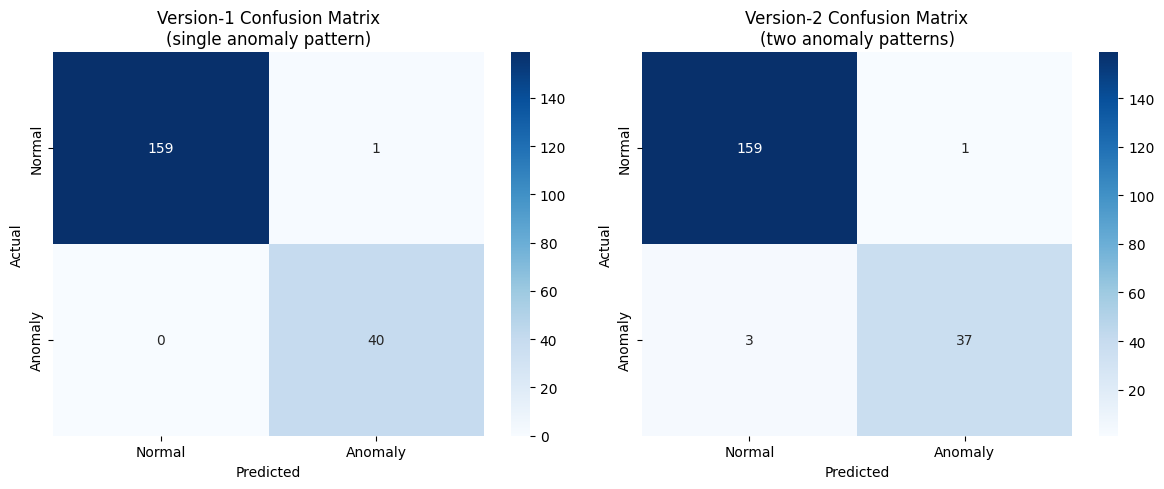

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# v1 confusion matrix (100% recall, single anomaly pattern)
cm_v1 = [[159, 1], [0, 40]]
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Version-1 Confusion Matrix\n(single anomaly pattern)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# v2 confusion matrix (92.5% recall, two anomaly patterns)
cm_v2 = [[159, 1], [3, 37]]
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_title('Version-2 Confusion Matrix\n(two anomaly patterns)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EnviroSense/documents/confusion_matrix_comparison.png')
plt.show()